# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [10]:
using LinearAlgebra
using Plots
using Plots.Measures
using Statistics
using Distributions
using KrylovKit
using Base.Threads

In [11]:
function jacobi(A, b, x0, ϵ; max_iter = 1000, boolean = false)
    n = length(b)
    x = copy(x0)
    x_new = similar(x)

    for k in 1:max_iter
        for i in 1:n
            sig = 0.0
            for j in 1:n
                if j != i
                    sig = sig + A[i, j] * x[j]
                end
            end
            x_new[i] = (b[i] - sig)/A[i, i]
        end

        # Criterio de convergencia residuo
        if norm(A*x_new -b) < ϵ
            if boolean
                return true
            end
            return x_new, k
        end

        x .= x_new
    end

    return false
end

jacobi (generic function with 1 method)

In [12]:
function gauss_seidel(A, b, x0, ϵ; max_iter = 1000, boolean = false)
    n = length(b)
    x = copy(x0)
    
    for k in 1:max_iter
        for i in 1:n
            sig = 0.0
            for j in 1:n
                if j != i
                    sig += A[i, j] * x[j]
                end
            end
            x[i] = (b[i] - sig)/A[i, i]
        end

        # Criterio de convergencia residuo
        if norm(A*x -b) < ϵ
            if boolean
                return true
            end
            return x, k
        end
    end

    return false
    
end

gauss_seidel (generic function with 1 method)

Qual deveria ser a complexidade computacional do código que você escreveu?

de forma intuitiva temos um while, dentro dele um for e dentro dele outro for, nos dois for realizamos operações "basicas" que numa analise assintotica não são consideradas então poderiamos dizer que tanto para jacobi como para gauss_seidel a complexidade é $O(n^2)$ a diferença é no while, chamemos de $k_j$ o numero de vezes que jacobi roda o while ate alcançar $\epsilon$ e $k_{gs}$ o numero de vezes que gauss seidel roda o while ate alcançar $\epsilon$, assim eles tem complexidade:

jacobi: $O(k_j \cdot n^2)$

gauss-seidel: $O(k_{gs} \cdot n^2)$

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [4]:
# Dados para o grafico
A1 = [2 1;
      5 7]

x01 = [0.0, 0.0]
b1 = [11, 13]

A2 = [7 2 4;
      1 4 2;
      1 0 3]

b2 = [23, 29, 11]
x02 = [0.0, 0.0, 0.0]

x = range(10^(-1), 10^(-99), 1000)
y_j = last.(jacobi.(Ref(A1), Ref(b1), Ref(x01), x))
y_gs = last.(gauss_seidel.(Ref(A1), Ref(b1), Ref(x01), x))

y_j1 = last.(jacobi.(Ref(A2), Ref(b2), Ref(x02), x))
y_gs1 = last.(gauss_seidel.(Ref(A2), Ref(b2), Ref(x02), x))
print()

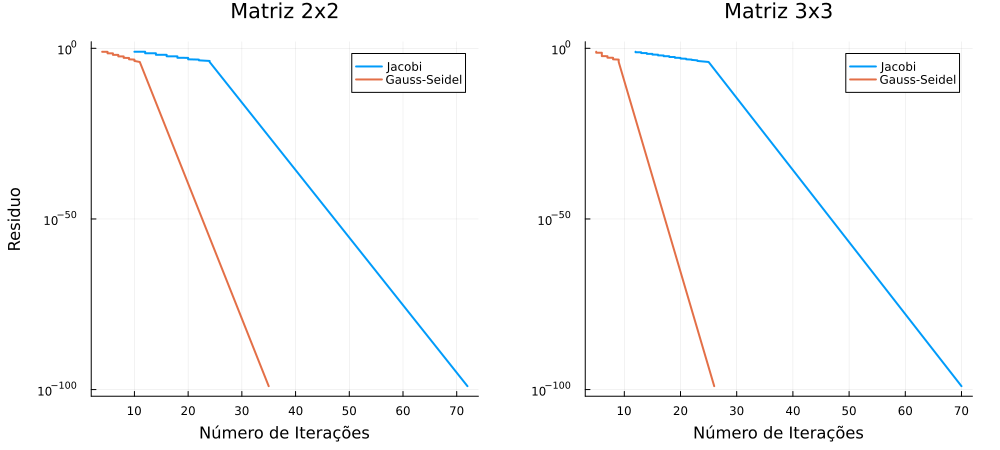

In [5]:
# Código gerando gráficos
p1 = plot(y_j, x, 
     yscale=:log10, 
     label="Jacobi", 
     lw=2, 
     xlabel="Número de Iterações",
     ylabel="Residuo",
     title="Matriz 2x2")

plot!(y_gs, x, 
      yscale=:log10, 
      label="Gauss-Seidel", 
      lw=2,
      )

p2 = plot(y_j1, x, 
     yscale=:log10, 
     label="Jacobi", 
     lw=2, 
     xlabel="Número de Iterações",
     title="Matriz 3x3")

plot!(y_gs1, x, 
      yscale=:log10, 
      label="Gauss-Seidel", 
      lw=2,
      )

plot(p1, p2, layout = (1, 2), size=(1000, 450), margin=5mm)

In [6]:
println("Para a matriz 2x2:", A1," Gauss-Seidel é, em media, " , mean(y_j ./ y_gs), " melhor em numero de iterações do que jacobi")
println("Para a matriz 3x3:", A2," Gauss-Seidel é, em media, " , mean(y_j1 ./ y_gs1), " melhor em numero de iterações do que jacobi")

Para a matriz 2x2:[2 1; 5 7] Gauss-Seidel é, em media, 2.40830404040404 melhor em numero de iterações do que jacobi
Para a matriz 3x3:[7 2 4; 1 4 2; 1 0 3] Gauss-Seidel é, em media, 2.4505212759462753 melhor em numero de iterações do que jacobi


Por velocidade entendo como quantidade de repetições ate que o algotimo, se convergir, atinja o $\epsilon$ desejado.

De acordo com os graficos realizados acima para matrizes 2x2 e 3x3 com valores inteiros o algoritmo de gauss seidel sempre converge mais rapido, em media gauss seidel é aproximadamente 2.5 vezes mais rapido do que jacobi, o que intuitivamente faz sentido pois gauss-seidel utiliza os valores atualizados para calcular novos $x_i$

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [7]:
# Dados para o grafico
s = 100
ϵ = 1e-10
intervalo = 2:s
y_j2 = []
y_gs2 = []

for m in intervalo
    A = rand(m,m)
    b = rand(m)
    x0 = zeros(m)

    push!(y_j2, jacobi(A, b, x0, ϵ))
    push!(y_gs2, gauss_seidel(A, b, x0, ϵ))
end

In [8]:
@show y_j2
@show y_gs2
print()

y_j2 = Any[false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false]
y_gs2 = Any[false, ([0.5149971397000767, -2.6551661377803075, 4.744258075276372], 121), false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false

Vimos em sala de aula que se uma matriz for diagonal dominante o metodo de jacobi converge, porem é dificil que matrizes rand(m, m) sejam diagonais dominantes pois cada entrada possui um valor aleatorio de 0 a 1, a distribuicao é uniforme logo todos os valores tem a mesma probabilidade então é muito improvavel que apareça uma matriz diagonal dominante, claro se a matriz não for fiagonal domiante ela ainda poderia convergir baixo outros criterios que não consigo detalhar porem como vemos acima para jacobi e gauss-saidel esses outros criterios para matrizes rand(m, m) são bastante improvaveis , testamos para matrizes 2x2 ate 100x100 repetindo ate converger a um epsilon pequeno (1e-10) ou ate realizar 1000 iterações.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

In [21]:
function k(m::Int)
    # 1. Calcula a probabilidade necessária por linha
    p_linha = 0.95^(1/m)
    
    # 2. Encontra o Z-score para essa probabilidade
    z_p = quantile(Normal(0, 1), p_linha)
    
    # Constantes da distribuição Half-Normal
    mu_half = sqrt(2/pi)
    var_half = 1 - (2/pi)
    
    # 3. Calcula E[D] e Var(D)
    E_D = -(m - 1) * mu_half
    Var_D = 1 + (m - 1) * var_half
    
    # 4. Aplica a fórmula final
    k = -E_D + z_p * sqrt(Var_D)
    return k
end

k (generic function with 1 method)

In [72]:
k_teorico = []

for i in 1:100
    push!(k_teorico, k(i))
end

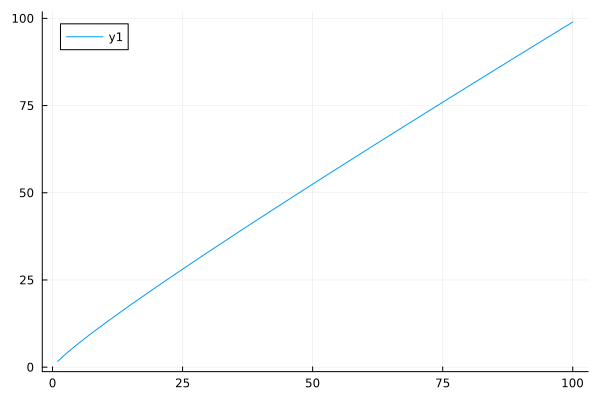

In [74]:
plot(1:100, k_teorico)

In [126]:
function k_convergencia_jacobi(m::Int; num_sim::Int=100)
    ks_necessarios = zeros(num_sim)
    
    println("Simulando convergência pelo Raio Espectral para matriz $(m)x$(m)...")
    
    for t in 1:num_sim
        M = randn(m, m)
        L_U = M - Diagonal(M)
        d_orig = diag(M)
        
        # Função que calcula o raio espectral de Jacobi dado um k adicionado
        function raio_espectral(k)
            # Evita divisão por zero se k anular exatamente um elemento da diagonal
            diag_vals = d_orig .+ k
            if any(x -> abs(x) < 1e-10, diag_vals)
                return Inf
            end
            
            D_inv = Diagonal(1.0 ./ diag_vals)
            T = -D_inv * L_U
            
            # Retorna o maior autovalor em módulo (raio espectral)
            return maximum(abs.(eigvals(T)))
        end
        
        # Se a matriz pura (k=0) já converge, o k necessário é 0 (ou menor)
        if raio_espectral(0.0) < 1.0
            ks_necessarios[t] = 0.0
            continue
        end
        
        # Define os limites para a busca binária
        k_min = 0.0
        k_max = 5.0
        
        # Aumenta k_max até o raio espectral cair abaixo de 1
        while raio_espectral(k_max) >= 1.0
            k_min = k_max
            k_max *= 2.0
        end
        
        # Busca binária para achar o k exato onde rho(T) == 1
        k_mid = 0.0
        for _ in 1:40 # 40 iterações garantem precisão absurda nas casas decimais
            k_mid = (k_min + k_max) / 2.0
            if raio_espectral(k_mid) >= 1.0
                k_min = k_mid # Ainda não converge, precisa de um k maior
            else
                k_max = k_mid # Converge, vamos tentar um k menor
            end
        end
        
        ks_necessarios[t] = k_mid
    end
    
    # Retorna o k que faz exatamente 95% das matrizes terem raio espectral < 1
    k_95 = quantile(ks_necessarios, 0.95)
    return k_95
end

k_convergencia_jacobi (generic function with 1 method)

In [ ]:
function k_convergencia_jacobi_krylov(m::Int; num_sim::Int=100)
    ks_necessarios = zeros(Float64, num_sim)
    
    println("Simulando convergência para matriz $(m)x$(m) usando KrylovKit")
    
    # Loop paralelizado para usar todos os núcleos do processador
    Threads.@threads for t in 1:num_sim
        M = randn(m, m)
        d_orig = diag(M)
        
        # Pré-alocando matriz de iteração uma única vez por simulação
        T = zeros(Float64, m, m)
        
        function raio_espectral(k::Float64)
            # Previne divisão por zero
            for i in 1:m
                if abs(d_orig[i] + k) < 1e-10
                    return Inf
                end
            end
            
            # Monta a matriz de Jacobi in-place (sem alocações novas)
            @inbounds for j in 1:m
                for i in 1:m
                    if i == j
                        T[i, i] = 0.0
                    else
                        T[i, j] = -M[i, j] / (d_orig[i] + k)
                    end
                end
            end
            
            # Usa o KrylovKit para achar APENAS o maior autovalor em módulo
            # Parâmetros: matriz T, qtde de autovalores (1), tipo (:LM = Largest Magnitude)
            try
                vals, _, _ = eigsolve(T, 1, :LM; ishermitian=false, tol=1e-4, maxiter=100)
                # vals é um vetor com o autovalor dominante, pegamos o módulo dele
                return abs(vals[1])
            catch
                # Em matrizes muito mal condicionadas, o método iterativo pode falhar.
                # Retornamos Inf para a busca binária saber que precisa de um k maior.
                return Inf
            end
        end
        
        # Lógica da Busca Binária inalterada
        if raio_espectral(0.0) < 1.0
            ks_necessarios[t] = 0.0
            continue
        end
        
        k_min = 0.0
        k_max = 5.0
        
        while raio_espectral(k_max) >= 1.0
            k_min = k_max
            k_max *= 2.0
        end
        
        k_mid = 0.0
        for _ in 1:40
            k_mid = (k_min + k_max) / 2.0
            if raio_espectral(k_mid) >= 1.0
                k_min = k_mid
            else
                k_max = k_mid
            end
        end
        
        ks_necessarios[t] = k_mid
    end
    
    return quantile(ks_necessarios, 0.95)
end

k_convergencia_jacobi_krylov (generic function with 1 method)

In [133]:
# Executando
m_teste = 50
k_real = k_convergencia_jacobi(m_teste)
println("\nO k(m) para que exatos 95% CONVIRJAM no Jacobi é: $(round(k_real, digits=4))")

Simulando convergência pelo Raio Espectral para matriz 50x50...

O k(m) para que exatos 95% CONVIRJAM no Jacobi é: 8.3586


In [134]:
m_teste = 50
k_real = k_convergencia_jacobi_krylov(m_teste)
println("\nO k(m) para que exatos 95% CONVIRJAM no Jacobi é: $(round(k_real, digits=4))")

Simulando convergência para matriz 50x50 usando KrylovKit...

O k(m) para que exatos 95% CONVIRJAM no Jacobi é: 8.512


In [ ]:
sucesso = 0.0

for i in 1:1000
    A = randn(50, 50) + 8.512*I 
    b = randn(50)
    x0 = zeros(50)

    sucesso += jacobi(A, b, x0, 1e-10, boolean=true)
end

println(sucesso/1000)

0.966


In [149]:
m = 2:100

k_exato = []

for i in m
    push!(k_exato, k_convergencia_jacobi_krylov(i))
end

Simulando convergência para matriz 2x2 usando KrylovKit...
Simulando convergência para matriz 3x3 usando KrylovKit...
Simulando convergência para matriz 4x4 usando KrylovKit...
Simulando convergência para matriz 5x5 usando KrylovKit...
Simulando convergência para matriz 6x6 usando KrylovKit...
Simulando convergência para matriz 7x7 usando KrylovKit...
Simulando convergência para matriz 8x8 usando KrylovKit...
Simulando convergência para matriz 9x9 usando KrylovKit...
Simulando convergência para matriz 10x10 usando KrylovKit...
Simulando convergência para matriz 11x11 usando KrylovKit...
Simulando convergência para matriz 12x12 usando KrylovKit...
Simulando convergência para matriz 13x13 usando KrylovKit...
Simulando convergência para matriz 14x14 usando KrylovKit...
Simulando convergência para matriz 15x15 usando KrylovKit...
Simulando convergência para matriz 16x16 usando KrylovKit...
Simulando convergência para matriz 17x17 usando KrylovKit...
Simulando convergência para matriz 18x18

In [166]:
m = 101:200

for i in m
    push!(k_exato, k_convergencia_jacobi_krylov(i))
end

Simulando convergência para matriz 101x101 usando KrylovKit...
Simulando convergência para matriz 102x102 usando KrylovKit...
Simulando convergência para matriz 103x103 usando KrylovKit...
Simulando convergência para matriz 104x104 usando KrylovKit...
Simulando convergência para matriz 105x105 usando KrylovKit...
Simulando convergência para matriz 106x106 usando KrylovKit...
Simulando convergência para matriz 107x107 usando KrylovKit...
Simulando convergência para matriz 108x108 usando KrylovKit...
Simulando convergência para matriz 109x109 usando KrylovKit...
Simulando convergência para matriz 110x110 usando KrylovKit...
Simulando convergência para matriz 111x111 usando KrylovKit...
Simulando convergência para matriz 112x112 usando KrylovKit...
Simulando convergência para matriz 113x113 usando KrylovKit...
Simulando convergência para matriz 114x114 usando KrylovKit...
Simulando convergência para matriz 115x115 usando KrylovKit...
Simulando convergência para matriz 116x116 usando Krylo

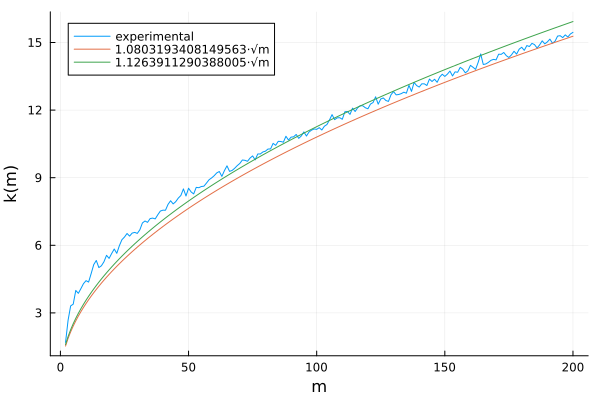

In [ ]:
intervalo = 2:200

c1 = quantile(Normal(0,1), 0.86)
y1 = c1*sqrt.(intervalo)

c2 = quantile(Normal(0,1), 0.87)
y2 = c2*sqrt.(intervalo)

plot(intervalo, k_exato, xlabel="m", ylabel="k(m)", label ="experimental")
plot!(intervalo,y1, label="$c1⋅√m")
plot!(intervalo,y2, label="$c2⋅√m")

In [308]:
c = quantile(Normal(0,1), 0.87)

1.1263911290388005

In [311]:
sucesso_j = 0.0
sucesso_gs = 0.0

n_sim = 100
m = 150
k_m = c*sqrt(m)

for i in 1:n_sim
    A = randn(m, m) + k_m*I
    b = randn(m)
    x0 = zeros(m)

    sucesso_j += jacobi(A, b, x0, 1e-10, boolean=true)
    sucesso_gs += gauss_seidel(A, b, x0, 1e-10, boolean=true)
end

println(sucesso_j/n_sim)
println(sucesso_gs/n_sim)

0.94
0.95


Confesso que é uma questão bem dificil, tentei varias coisas, deixei no arquivo apenas duas ideias, minha primeira ideia era calcular que tão grande precisa ser k(m) para que a minha matriz seja diagonal dominante, esse problema consegui entender e solucionar com ajuda, esses valores de k(m) geralmente tinham uma taxa de acertos maior que 95%. Então de acordo com o que foi falado em monitoria percebi que o mais importante é o raio espectral, se eu conseguir garantir um raio espectral menor que 1 minha matriz ira convergir, então usei o codigo acima que realiza uma simulação para achar um valor aproximado de k(m) em 95% dos casos me retorne um raio espectral (para jacobi) menor do que 1, a partir desse plot percebi que tinha um crescimento parecido com a raiz quadrada, então usei o modelo $c\cdot\sqrt{m}$ e para os valores de c testei quantis da distribuicao normal, o motivo pelo qual usei quantis não o tenho muito claro, confesso que muitas das coisas que realizei não estão muito claras na minha cabeça mas mudei a perspectiva da questão a algo experimentativo, ou seja, usando tudo o que eu conheço e consigo compreender minimamente tentei achar pelo menos uma aproximação de k(m) sem me limitar compender com profundessa a teoria, a forma que achei os quantis foi empiricamente, observando para os dados simulados e escolhendo a curva que melhor se aproximasse

realizando testes para alguns valores de m e escolhendo o valor aproximado pelo grafico conseguir bons resultados para alguns valores de m, perto de 95%, pode se observar isso rodando a celula acima algumas vezes, trocando o valor de m e o numero de tentativas n_sim 

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

Queremos uma matriz tal que o raio espectral de jacobi seja menor que o raio espectral de Gauss-Seidel e que tanto jacobi como gauss-seidel funcionem ou seja que o raio espectral da ambas seja maior que um.

Para que jacobi seja melhor que gauss seidel, vamos fazer com que a matriz $M_{j}$ seja diagonalizavel e nilpotente, assim todos os teus atuvalores serão 0 pois $M_{j}^{k} = 0$ para algum k natural, mas como $M_{j} = S\Lambda S^{-1}$ teremos que $M_{j}^{k} = S\Lambda^{k} S^{-1} = 0$ logo $\Lambda = 0$ dessa forma o raio espectral de jacobi seria 0, porem não queremos que isso aconteça com $M_{gs}$ queremos que o raio espectral de gauss-seidel seja maior que 0 e menor que 1 para gauss-seidel tambem convergir, no livro Numerical Analysis (Análise Numérica) – Richard L. Burden e J. Douglas Faires na seção que fala sobre jacobi e gauss-seidel na parte dos problemas ha um problema que propoe o mesmo com uma matriz 3x3, a matriz 3x3 fornecida é a seguinte:

$$
A =

\begin{bmatrix}
1 & 2 & -2 \\
1 & 1 & 1 \\
2 & 2 & 1
\end{bmatrix}
$$

esta matriz quase atende as nossas necessidades pois $\rho(M_{gs}) = 2$ mas queremos que seja menor que 1, vamos então parametrizar a matriz $A$ para controlar o valor dos autovalores de gauss_seidel, da seguinte maneira:

$$
A(\alpha) =

\begin{bmatrix}
1 & 2\alpha & -2\alpha \\
\alpha & 1 & \alpha \\
2\alpha & 2\alpha & 1
\end{bmatrix}
$$

percebemos que $M_{j}$ ainda possui todos os autovalores iguais a 0, pois eles apenas são multiplicados por um fator $\alpha$, agora vamos calcular os autovalores de gauss-seidel:

$det(\lambda I - T_{gs}(\alpha)) = 0$

calculando essa matriz achamos:

$$
\lambda I - T_{GS}(\alpha) =

\begin{bmatrix}
\lambda & 2\alpha & -2\alpha \\
0 & \lambda - 2\alpha^{2} & 2\alpha^{2} + \alpha \\
0 & 4\alpha^{3} - 4\alpha^2 & \lambda - 4\alpha^{3} + 2\alpha^{2}
\end{bmatrix}
$$

fazendo contas achamos o seguinte polinomio caracteristico:

$$\det(\lambda I - T_{GS}(\alpha)) = \lambda(\lambda^2 - 4\alpha^3\lambda + 4\alpha^3) = 0$$

então 0 é um dos autovalores, os outros dois achamos resolvendo a equação quadratica

$$\lambda^2 - 4\alpha^3\lambda + 4\alpha^3 = 0 $$

 porem como queremos um valor de alpha entre (0, 1) pois se tivessemos alphas maiores o valor de o valor os autovalores sera maior, porem se alpha esta nesse intervalo nosso discriminante é negativo pois: $\Delta = 16\alpha^{3}(\alpha^{3} - 1)$ e $\alpha^{3} < 1$ logo $\sqrt\Delta = i\sqrt{16\alpha^3(1 - \alpha^3)}$

$$\sqrt{\Delta} = i \cdot 4\alpha^{3/2}\sqrt{1 - \alpha^3}$$, temos então nossas duas raizes $$\lambda = 2\alpha^3 \pm i \cdot 2\alpha^{3/2}\sqrt{1 - \alpha^3}$$

neste caso o raio espectral é a norma desses vetores, como são vetores conjugados ambos possuem a mesma norma, assim fazendo as contas obtemos:

$$|\lambda| = \sqrt{4\alpha^3}$$

queremos que essa norma seja menor do que 1 para que gauss-seidel funcione, assim:

$$\alpha < \sqrt[3]{\frac{1}{4}}$$

podemos escolher um alpha mais bonito, como $1/2$ e nossa matriz A(1/2) sera:

$$A = \begin{pmatrix} 1 & 1 & -1 \\ 0.5 & 1 & 0.5 \\ 1 & 1 & 1 \end{pmatrix}$$

agora podemos criar uma matriz 4x4 em blocos que apenas adicionara um novo autovalor 0, logo não destruira a dinamica que contruimos com a matriz 3x3, finalmente obtemos:

$$A = \begin{pmatrix} 1 & 1 & -1 & 0 \\ 0.5 & 1 & 0.5 & 0 \\ 1 & 1 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

com A convergindo mais rapido para jacobi do que gauss-seidel, a seguir o codigo para confirmar nossa teoria:

In [231]:
# Código
A = [1   1 -1   0;
     0.5 1  0.5 0;
     1   1  1   0;
     0   0  0   1]

b = [1,2,3,4]
x0 = zeros(4)

@show jacobi(A, b, x0, 1e-16)
@show gauss_seidel(A, b, x0, 1e-16)
print()

jacobi(A, b, x0, 1.0e-16) = ([1.0, 1.0, 1.0, 4.0], 3)
gauss_seidel(A, b, x0, 1.0e-16) = ([1.0, 1.0, 1.0, 4.0], 106)


## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [297]:
# Código

err = rand(4,4)/50

A_perturbed = A + err
println(jacobi(A_perturbed, b, x0, 1e-16))
println(gauss_seidel(A_perturbed, b, x0, 1e-16))
println()

A_perturbed_d = A + err - diagm(diag(err))

println(jacobi(A_perturbed_d, b, x0, 1e-16))
println(gauss_seidel(A_perturbed_d, b, x0, 1e-16))
println()

([0.9801990943457854, 0.967920439571763, 0.9924448396372614, 3.9034605079240667], 22)
([0.9801990943457852, 0.9679204395717632, 0.9924448396372614, 3.9034605079240667], 106)

([0.9706870920759457, 0.9837786632081309, 0.9946342281572313, 3.980756731823008], 27)
false



Se somarmos uma matriz pequena a matriz A acima podemos interpretar isso como o sistema que ja timos com um pouco de erro, logo se o erro é pequeno deveriamos ter um comportamento aproximado.

depois de observar varias vezes, dependedo do valor da perturbação pode acontecer qualquer coisa, no sentido: os dois podem convergir, ou so gauss-seidel ou so jacobi, ou os dois podem divergir, porem nos casos em que os dois convergem, jacobi sempre é melhor do que gauss-seidel ainda.

percebo que essa perturbação destrui a nossa nilpotencia pois jacobi não converge com exatamente 3 iterações, e a perturbação afeta mais jacobi do que gauss-seidel pois a quantidade de iterações de gauss-seidel não varia muito comparando a quando não tinhamos perturbação

se essa perturbação acontecer apenas fora da diagonal a interpretação pode ser a mesma, temos dados com erro porem agora temos menos erro, e novamente afeta mais jacobi do que gauss-seidel, porem como o raio espectral de jacobi era 0, por construção,faz com que ainda seja melhor do que gauss-seidel